## Variável Quantitativa Discreta — Unidades Produzidas

Este notebook atende ao critério **"Tabela com a distribuição de frequências da variável qualitativa e representação gráfica"** e ao critério **"Medidas resumo para a variável quantitativa"** da rubrica da sprint 1.

**Base de dados:** `Eficiencia Operacional em Linhas de Producao.xlsx` (n = 1000 linhas de produção)

**Variável analisada:** `Unidades_Produzidas` — quantitativa **discreta**.

#### 1. Importando as bibliotecas

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import math

#### 2. Definindo a variável "arquivo" pelo nome da planilha e a variável "coluna" com a variável "coluna" como a variável de analise neste caso Unidades_Produzidas

In [20]:
arquivo = 'refs/Eficiencia Operacional em Linhas de Producao.xlsx'
coluna = 'Unidades_Produzidas'

#### 3. Importando e lendo a base de dados da planilha via script

In [21]:
df = pd.read_excel(arquivo)
df

,Nivel_Automacao,Tempo_Ciclo_s,Unidades_Produzidas
0,Alta,52.42,523
1,Baixa,43.03,643
2,Média,58.33,421
3,Baixa,55.95,495
4,Alta,36.54,832
...,...,...,...
995,Baixa,54.31,446
996,Média,49.62,601
997,Alta,51.04,597
998,Média,57.56,400


#### 4. Encontrando e calculando os parâmetros para montar a tabela de classes

##### 4.1 Encontrando os parâmetros

In [22]:
# Encontrando os valores máximos e mínimos dos dados
valormin = df[coluna].min()
valormax = df[coluna].max()
delta = valormax - valormin

# Encontrando a quantidade unitária de amostras
n = df[coluna].count()

# Encontrando a quantidade de classes
# OBS: o comando math.ceil serve para realizar um arredondamento para cima
# do valor calculado dentro do parâmetro dele, neste caso a raiz de N
k = math.ceil(math.sqrt(n))

# Calculando amplitude de cada classe
amplitude = round(delta/k,2)

# Imprimindo os parâmetros encontrados
print(f'Parâmetro da base de dados calculados'
      f'\nValor máximo de unidades produzidas dos dados: {valormax}'
      f'\nValor Mínime de unidades produzidas dos dados: {valormin}'
      f'\nDiferença entre máximo e mínimo: {delta}'
      f'\nQuantidade unitária de amostras encontradas: {n}'
      f'\nQuantidade de classes calculadas: {k}'
      f'\nAmplitude calculada por classe: {amplitude}')

Parâmetro da base de dados calculados
Valor máximo de unidades produzidas dos dados: 1200
Valor Mínime de unidades produzidas dos dados: 211
Diferença entre máximo e mínimo: 989
Quantidade unitária de amostras encontradas: 1000
Quantidade de classes calculadas: 32
Amplitude calculada por classe: 30.91


##### 4.2 Encontrando os parâmetros

In [23]:
# Calculando o limite inferior das classes
# OBS: Nãio foi utilizado o comando math.floor que serve para arredondar
# o valor, pois o valor mínimo de unidades produzidas é um número inteiro,
# logo não há necessidade de arredondamento.
limite_inferior = valormin

# Criando a array de classes de maneira dinâmica
classes = []
i = 0
while True:
    # calcula o limite fazendo o valor de limite inferior + i X amplitude
    # e por fim arredonda o valor para 2 casas decimais o limite
    limite = round(limite_inferior + i * amplitude,2)

    # Pega o valor do limite e adiciona na lista de classes como um novo
    # elemento na array de classes
    classes.append(limite)

    # Se o limite for maior que o valor máximo da variável analisada,
    # então o loop é interrompido e segue para o print da quantidade
    # de classes encontradas e a lista de classes
    if limite > valormax:
        break

    # Soma 1 no valor de i
    i += 1

print(classes)
print(f'Quantidade de classes encontradas: {len(classes)}')

[211.0, 241.91, 272.82, 303.73, 334.64, 365.55, 396.46, 427.37, 458.28, 489.19, 520.1, 551.01, 581.92, 612.83, 643.74, 674.65, 705.56, 736.47, 767.38, 798.29, 829.2, 860.11, 891.02, 921.93, 952.84, 983.75, 1014.66, 1045.57, 1076.48, 1107.39, 1138.3, 1169.21, 1200.12]
Quantidade de classes encontradas: 33


#### 5. Encontrando a frequência absoluta, frequência relativa e frequência acumulada

In [24]:
# Calculando a frequência absoluta da coluna de unidades produzidas,
# utilizando o metodo 'pd.cut()' para criar as classes e o metodo
# 'value_counts()' para contar a frequências absolutas de valores
# em cada classe.
frequencia = pd.cut(x=df[coluna], bins=classes, include_lowest=True, right=False).value_counts()
frequencia = frequencia.sort_index()

# Calculando frequência relativa (%) da coluna de unidades produzidas,
# utilizando o metodo 'pd.cut()' para criar as classes e o metodo
# 'value_counts(normalize=True)' para contar a frequências relativas
# de valores em cada classe.
frequencia_relativa = round(pd.cut(x=df[coluna], bins=classes, include_lowest=True, right=False).value_counts(normalize=True) * 100,2)
frequencia_relativa = frequencia_relativa.sort_index()

# Calculando a frequência absoluta acumulada da coluna de unidades
# produzidas, utilizando o metodo 'cumsum()' para somar os valores
# de frequências absolutas de cada classe com as frequências absolutas
# das classes anteriores.
frequencia_acumulada = frequencia.cumsum()

# Calculando a frequência relativa acumulada da coluna de unidades
# produzidas, utilizando o metodo 'cumsum()' para somar os valores
# de frequências relativas de cada classe com as frequências relativas
# das classes anteriores.
frequencia_relativa_acumulada = frequencia_relativa.cumsum()


#### 6. Montando a tabela de frequências

In [25]:
# Montando a tabela de frequências com as frequências absolutas,
# frequências relativas, frequências absolutas acumuladas e frequências
# relativas acumuladas, utilizando o metodo 'pd.DataFrame()' para criar
# a tabela de frequências.
dist_freq = pd.DataFrame({
    'Frequência Absoluta': frequencia,
    'Frequência Relativa (%)': frequencia_relativa,
    'Frequência Absoluta Acumulada': frequencia_acumulada,
    'Frequência Relativa Acumulada': frequencia_relativa_acumulada,
})

# Resetando o index da tabela de frequências para que a coluna de classes
# seja a primeira coluna da tabela de frequências, utilizando o metodo
# 'reset_index()' para resetar o index da tabela de frequências.
dist_freq = dist_freq.reset_index()

# Renomeando as colunas da tabela de frequências para que fiquem mais
# legíveis, utilizando o metodo 'columns' para renomear as colunas da
# tabela de frequências.
dist_freq.columns = {
    'Classes de Unidades Produzidas',
    'Frequência Absoluta',
    'Frequência Relativa',
    'Frequência Absoluta Acumulada',
    'Frequência Relativa Acumulada (%)'
}

# Convertendo a coluna de classes de unidades produzidas para o tipo
# string, utilizando o metodo 'astype(str)' para converter a coluna
# de classes de unidades produzidas para o tipo string.
dist_freq['Classes de Unidades Produzidas'] = dist_freq['Classes de Unidades Produzidas'].astype(str)

print(f'      Variável: {coluna} (unidades)')
print('      *Limites superiores do intervalo de classes incluídos')
dist_freq

      Variável: Unidades_Produzidas (unidades)
      *Limites superiores do intervalo de classes incluídos


,Classes de Unidades Produzidas,Frequência Relativa,Frequência Absoluta,Frequência Absoluta Acumulada,Frequência Relativa Acumulada (%)
0,"[211.0, 241.91)",6,0.6,6,0.6
1,"[241.91, 272.82)",4,0.4,10,1.0
2,"[272.82, 303.73)",5,0.5,15,1.5
3,"[303.73, 334.64)",12,1.2,27,2.7
4,"[334.64, 365.55)",12,1.2,39,3.9
5,"[365.55, 396.46)",28,2.8,67,6.7
6,"[396.46, 427.37)",43,4.3,110,11.0
7,"[427.37, 458.28)",67,6.7,177,17.7
8,"[458.28, 489.19)",56,5.6,233,23.3
9,"[489.19, 520.1)",74,7.4,307,30.7


#### 7. Construindo os gráficos para demonstração

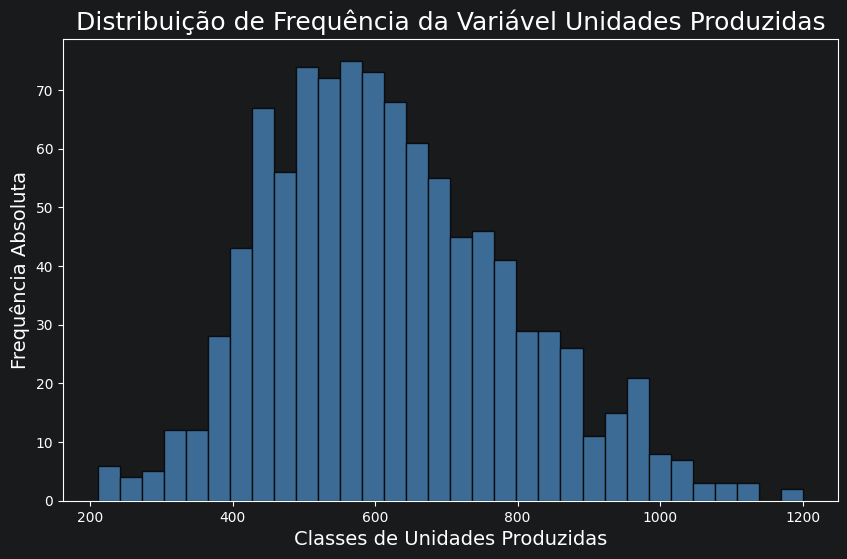

In [26]:
# 7.1. Construindo o Histograma da variável Unidades Produzidas
fig, ax = plt.subplots(figsize=(10, 6))

# Construindo o histograma da variável Unidades Produzidas, utilizando
# o metodo 'plt.hist()' para criar o histograma
plt.hist(df[coluna], bins=classes, rwidth=1, color='steelblue', alpha=0.8, edgecolor='black')

# Configurando o gráfico, Define o título e descrição dos eixos do gráfico
# e seus respectivos tamanhos de cada texto
ax.set_title('Distribuição de Frequência da Variável Unidades Produzidas', fontsize=18)
ax.set_xlabel('Classes de Unidades Produzidas', fontsize=14)
ax.set_ylabel('Frequência Absoluta', fontsize=14)
plt.tick_params(labelsize=10)

# Printa o gráfico na tela
plt.show()

#### 8. Calculando e analisando as medidas e métricas estatísticas

In [27]:
# Calculando a média dos dados analisados, utilizando o metodo 'mean()' para calcular a
# média dos dados.
media = round(df[coluna].mean(), 2)

# Calculando a mediana dos dados analisados, utilizando o metodo 'median()' para calcular
# a mediana dos dados.
mediana = round(df[coluna].median(), 2)

# Calculando a moda dos dados analisados, utilizando o metodo 'mode()' para calcular a moda
# dos dados, o parâmetro [0] é para certificar que começa na posição 1 da tabela.
moda = df[coluna].mode()[0]

# Calculando a classe modal dos dados analisados, utilizando o metodo 'idxmax()' para encontrar
# o índice da linha com a maior frequência absoluta
linha_modal = dist_freq.loc[dist_freq['Frequência Absoluta'].idxmax()]
classe_modal = linha_modal['Classes de Unidades Produzidas']

# Printa as métricas estatísticas calculadas na tela
print(f'Média: {media}\n'
      f'Mediana: {mediana}\n'
      f'Moda: {moda}\n'
      f'Classe Modal: {classe_modal}(frequência = {linha_modal["Frequência Absoluta"]})')

Média: 621.7
Mediana: 601.0
Moda: 488
Classe Modal: [551.01, 581.92)(frequência = 7.5)


#### 9. Conclusão **Interpretando as medidas de resumo — Unidades_Produzidas**

**Média (621,7 unidades produzidas):** em média, em cada linha de produção da fabrica aproximadamente 621,7 unidades são produzidas no período analisado.

**Mediana (601 unidades produzidas):** metade das observações produziu até 601 unidades, e a outra metade produziu mais que isso.

**Moda (488 unidades produzidas):** Como a variavel tem 509 valores distintos em 1000 amostras, a moda tem baixa relevância estatística, pois analisa as amostras e não em cima das classes por isto calcular a classe modal, ou seja, o conjunto de valores que representa um intervalo que mais aparece.

**Classe Modal ([551,01; 581,92) unidades produzidas):** é a faixa de produção que mais se repete, ou seja, a faixa de produção que mais aparece na amostra analisada. A classe modal é uma medida de tendência central que indica o conjunto de valores mais frequente em um conjunto de dados. Neste caso, a classe modal indica que a maioria das linhas de produção produziu entre 551,01 e 581,92 unidades no período analisado. Bem mais relevante estatísticamente do que a moda, pois analisa as amostras e não em cima das classes e não em cima de valores unitários.